In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
import jax
import ml_confs
import xarray as xr

from spectraformer.input_pipeline import preprocess_dataset, preprocess_dataset_raw

jax.config.update("jax_debug_nans", True)

maindir = Path('/home/dpoteryayev/SpectraFormer/Poisson check.ipynb').parent.resolve()

logdir = maindir / "logs"
ckptdir = maindir / "checkpoints"
# Check if logdir and ckptdir exist, if not create them
logdir.mkdir(parents=True, exist_ok=True)
ckptdir.mkdir(parents=True, exist_ok=True)

datadir = maindir / "data"

model_tag = "min8"  # CHOOSE ONE (.yaml file should exist)
                    # tag also can be found for already trained models in checkpoints folder

configsdir = maindir / "configs"
configsdir.mkdir(parents=True, exist_ok=True)

config_file_name = f"configs_{model_tag}.yaml"
config_file_path = configsdir / config_file_name

configs = ml_confs.from_file(config_file_path)
configs.tabulate()

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Key                    ┃ Value              ┃ Type      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ tag                    │ spectraformer:min8 │ str       │
│ embedding_dim          │ 64                 │ int       │
│ num_heads              │ 8                  │ int       │
│ num_layers             │ 2                  │ int       │
│ learning_rate          │ 0.0001             │ float     │
│ num_epochs             │ 600                │ int       │
│ batch_size             │ 19                 │ int       │
│ dropout_rate           │ 0.5                │ float     │
│ root_rng_seed          │ 0                  │ int       │
│ train_dataset          │ SiC_19x10x3        │ str       │
│ log_every_epochs       │ 5                  │ int       │
│ masked_interval_starts │ [1000, 2500]       │ list[int] │
│ masked_interval_ends   │ [1700, 2900]       │ list[int] │
└────────────────────────┴────────────────────┴───────────┘

In [11]:
# Load the full dataset
full_ds = preprocess_dataset(
    xr.load_dataarray(datadir / f"{configs.train_dataset}.nc")
) - 0.1

mean_values = full_ds.mean(
    dim=['spectra']
)

variance_values = full_ds.var(
    dim=['spectra']
)

std_values = full_ds.std(
    dim=['spectra']
)

scale_param_values = variance_values / mean_values

shape_param_values = mean_values**2 / std_values**2

full_ds

Dropped 0 spectra


<xarray.DataArray (wave_number: 1015, spectra: 570)>
array([[0.06321972, 0.06322556, 0.07688599, ..., 0.06697275, 0.07813979,
        0.08525848],
       [0.07789186, 0.06324255, 0.08054267, ..., 0.05904082, 0.07665442,
        0.07776609],
       [0.07257985, 0.06325956, 0.07146665, ..., 0.06568322, 0.07817971,
        0.07402785],
       ...,
       [0.02190699, 0.01672867, 0.01595614, ..., 0.02191288, 0.01717111,
        0.01904489],
       [0.01359051, 0.02230961, 0.0182329 , ..., 0.02026475, 0.02093749,
        0.01670395],
       [0.01026167, 0.0111595 , 0.02050487, ..., 0.01364431, 0.01529626,
        0.03782147]])
Coordinates:
  * wave_number  (wave_number) float64 1.278e+03 1.28e+03 ... 2.819e+03 2.82e+03
  * spectra      (spectra) object MultiIndex
  * X_0          (spectra) int64 0 0 0 0 0 0 0 0 0 ... 19 19 19 19 19 19 19 19
  * X_1          (spectra) int64 0 0 0 1 1 1 2 2 2 3 3 ... 6 6 7 7 7 8 8 8 9 9 9
  * X_2          (spectra) int64 0 2 4 0 2 4 0 2 4 0 2 ... 2 4 0 2 4 0 2 4 0 2 4

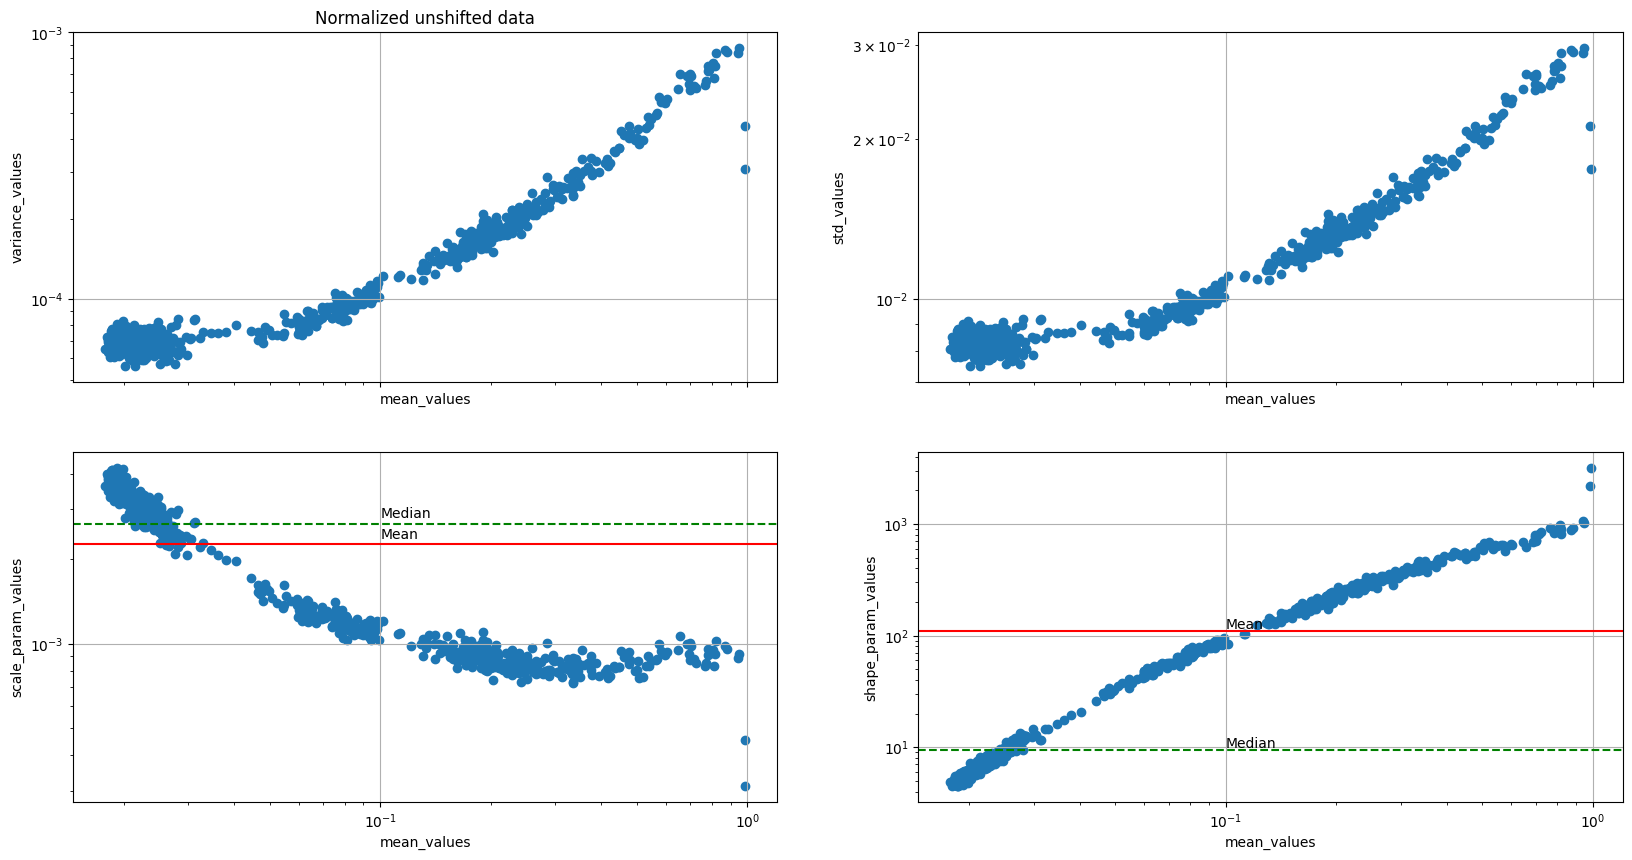

In [13]:
fig = plt.figure(figsize=(20, 10))
axes = fig.subplots(2, 2, sharex=True)

axes[0,0].scatter(x=mean_values, y=variance_values)
axes[0,0].set_xlabel('mean_values')
axes[0,0].set_ylabel('variance_values')
axes[0,0].set_title('Normalized unshifted data')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,0].grid(visible=True, which='major', axis='both')

axes[0,1].scatter(x=mean_values, y=std_values)
axes[0,1].set_xlabel('mean_values')
axes[0,1].set_ylabel('std_values')
# axes[0,1].set_title('Normalized data')
axes[0,1].set_yscale('log')
axes[0,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[0,1].grid(visible=True, which='major', axis='both')

axes[1,0].scatter(x=mean_values, y=scale_param_values)
axes[1,0].set_xlabel('mean_values')
axes[1,0].set_ylabel('scale_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,0].set_yscale('log')
axes[1,0].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,0].grid(visible=True, which='major', axis='both')
axes[1,0].axhline(y=scale_param_values.mean(), color='r', linestyle='-')
axes[1,0].annotate('Mean', ( 1e-1, 1.05*scale_param_values.mean()))
axes[1,0].axhline(y=scale_param_values.median(), color='g', linestyle='--')
axes[1,0].annotate('Median', ( 1e-1, 1.05*scale_param_values.median()))

axes[1,1].scatter(x=mean_values, y=shape_param_values)
axes[1,1].set_xlabel('mean_values')
axes[1,1].set_ylabel('shape_param_values')
# axes[0,1].set_title('Normalized data')
axes[1,1].set_yscale('log')
axes[1,1].set_xscale('log')
# ax.set_xlim([8e-6,3e0])
# ax.set_ylim([1e-5,1e-3])
axes[1,1].grid(visible=True, which='major', axis='both')
axes[1,1].axhline(y=shape_param_values.mean(), color='r', linestyle='-')
axes[1,1].annotate('Mean', ( 1e-1, 1.05*shape_param_values.mean()))
axes[1,1].axhline(y=shape_param_values.median(), color='g', linestyle='--')
axes[1,1].annotate('Median', ( 1e-1, 1.05*shape_param_values.median()))

plt.show()